# Phase 6 — Statistical Forecasting (ARIMA / SARIMA)
### Energy Demand Forecasting Project

**Question this phase answers:** can a classical statistical model beat the
Phase 5 baseline bar (daily seasonal naive: MAE 0.530, RMSE 0.786) at the
24-hour-ahead horizon?

Two models fit here, deliberately, for comparison:
- **Plain ARIMA** (no seasonal component) — isolates how much value the
  seasonal term actually adds.
- **SARIMA with m=24** (daily seasonality) — m=168 (weekly) is computationally
  intractable with statsmodels' state-space implementation, and Phase 5
  already showed daily lag beats weekly lag as a plain baseline, so this
  isn't just a shortcut.

Same shared train/test split and forecast origins as Phase 5, so the
comparison is fair.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
import mlflow
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.evaluation.splits import get_train_test_split
from src.evaluation.baselines import get_forecast_origins, compute_metrics, HORIZON
from src.evaluation.results_store import save_results
from src.models.sarima import stationarity_tests, fit_model, rolling_backtest

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")


## Load data and reuse the shared Phase 5 split

In [3]:
con = duckdb.connect("../data/energy.duckdb", read_only=True)
hourly = con.execute("SELECT datetime, global_active_power FROM hourly ORDER BY datetime").df()
con.close()

hourly["datetime"] = pd.to_datetime(hourly["datetime"])
series = hourly.set_index("datetime")["global_active_power"]
series = series.asfreq("h")  # explicit hourly frequency, so downstream slices behave predictably

test_start = get_train_test_split(series, test_frac=0.2)
train = series.loc[:test_start]
train = train.asfreq("h")  # .loc slicing drops freq -- restore it explicitly
origins = get_forecast_origins(series, test_start, horizon=HORIZON)

print(f"Test starts: {test_start} | Train hours: {len(train):,} | Origins: {len(origins)}")


Test starts: 2010-02-11 00:00:00 | Train hours: 27,656 | Origins: 288


## Stationarity testing (ADF & KPSS)

Testing the raw training series, then the first difference, to decide the
differencing order `d`.


In [4]:
print("=== Raw series ===")
stationarity_tests(train)

print("\n=== First difference ===")
stationarity_tests(train.diff().dropna())


=== Raw series ===


/Users/apple/Documents/Projects/energy-demand-forecast/src/models/sarima.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, nlags="auto")


ADF:  statistic=-12.6028, p-value=0.0000 (stationary per ADF)
KPSS: statistic=1.0624, p-value=0.0100 (non-stationary per KPSS)

=== First difference ===
ADF:  statistic=-37.6491, p-value=0.0000 (stationary per ADF)
KPSS: statistic=0.0227, p-value=0.1000 (stationary per KPSS)


/Users/apple/Documents/Projects/energy-demand-forecast/src/models/sarima.py:35: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(clean, nlags="auto")


{'adf_statistic': np.float64(-37.64914482916983),
 'adf_pvalue': 0.0,
 'kpss_statistic': np.float64(0.022745607605818154),
 'kpss_pvalue': np.float64(0.1)}

## ACF / PACF at hourly grain

Zoomed to 72 lags (3 days) to clearly see the daily spike at lag 24 (and 48)
that the seasonal term needs to capture.


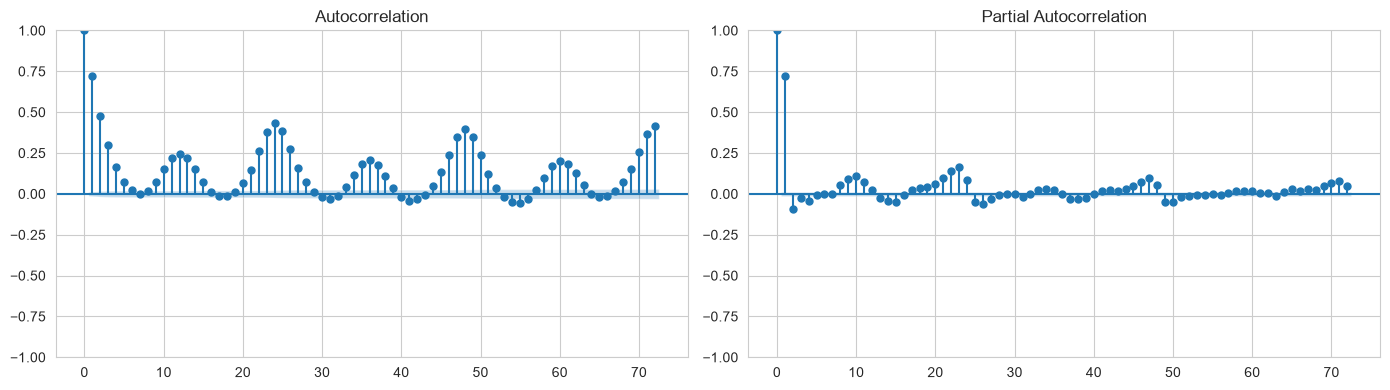

In [5]:
train_filled = train.interpolate(limit_direction="both")  # ACF/PACF plotting needs no NaNs

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_filled, lags=72, ax=axes[0])
plot_pacf(train_filled, lags=72, ax=axes[1])
plt.tight_layout()
plt.show()


## Order search (auto_arima)

**Assumption flagged:** running `auto_arima` on the full ~27,600-hour
training set with seasonal m=24 would be extremely slow. Searching on the
most recent 60 days (1,440 hours) instead -- recent data is what matters
most for a model that only captures daily seasonality (no long-term trend
was found in Phase 2 anyway). `auto_arima` requires complete data for its
search, so this subset is interpolated -- this interpolation is ONLY for the
search step, not for the final model fit below.


In [6]:
search_subset = train.iloc[-1440:].interpolate(limit_direction="both")

auto_model = pm.auto_arima(
    search_subset,
    seasonal=True, m=24,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    d=None, D=None,
    stepwise=True, trace=True,
    error_action="ignore", suppress_warnings=True,
)
print(auto_model.summary())

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f"\nSelected order: {order}, seasonal_order: {seasonal_order}")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=4.77 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=3124.081, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=3021.336, Time=0.52 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=3044.265, Time=0.51 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=3122.081, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=3121.876, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=2980.054, Time=2.95 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=14.49 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.96 sec
 ARIMA(0,1,0)(2,0,0)[24] intercept   : AIC=3004.937, Time=2.08 sec
 ARIMA(2,1,0)(2,0,0)[24] intercept   : AIC=2948.680, Time=3.55 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=2996.581, Time=0.67 sec
 ARIMA(2,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=16.74 sec
 ARIMA(2,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.63 sec
 ARIMA(3,1,0)(2,0,0)[24] intercept   : AIC

## Fit final ARIMA and SARIMA models

**Assumption flagged:** fitting on the most recent ~6 months of training
data (4,380 hours), not the full 4 years -- SARIMA with m=24 only models
daily seasonality, so multi-year history adds fitting cost without adding
relevant signal (no long-term trend was found in Phase 2 either). This means
neither model captures annual seasonality -- a real limitation, worth
carrying into the model comparison discussion in Phase 9.

Passed directly to statsmodels (not interpolated) -- the Kalman filter
handles the known data gaps as missing observations natively.


In [7]:
fit_window = train.iloc[-4380:]
fit_window = fit_window.asfreq("h")  # .iloc slicing drops freq -- restore it explicitly
print(f"Fitting on {len(fit_window):,} hours: {fit_window.index.min()} to {fit_window.index.max()}")

arima_fit = fit_model(fit_window, order=order, seasonal_order=(0, 0, 0, 0))
sarima_fit = fit_model(fit_window, order=order, seasonal_order=seasonal_order)

print(f"\nARIMA AIC: {arima_fit.aic:.1f}")
print(f"SARIMA AIC: {sarima_fit.aic:.1f}")


Fitting on 4,380 hours: 2009-08-12 13:00:00 to 2010-02-11 00:00:00

ARIMA AIC: 8994.5
SARIMA AIC: 8531.4


## Residual diagnostics (SARIMA)

Four-panel diagnostic: standardized residuals over time, histogram vs normal
density, Q-Q plot, and residual correlogram. Plus an explicit Ljung-Box test
for residual autocorrelation (null: residuals are white noise -- a good
model's residuals should NOT be significantly autocorrelated).


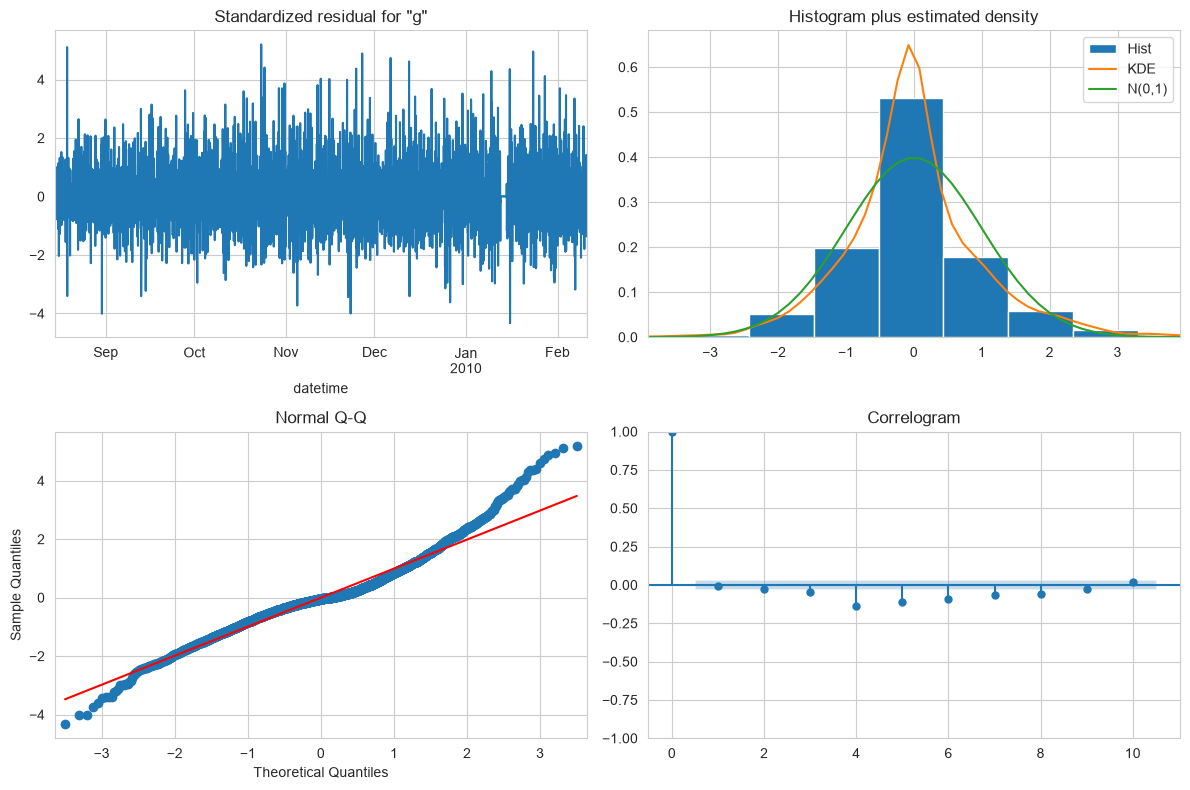

       lb_stat     lb_pvalue
24  214.078297  1.922606e-32
48  343.111045  3.429789e-46


In [8]:
sarima_fit.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(sarima_fit.resid.dropna(), lags=[24, 48], return_df=True)
print(lb_test)


## Rolling-origin backtest

Both models walk forward through every test-period origin using
`.append(refit=False)` -- parameters stay fixed after the initial fit above;
only the model's internal state is kept current with new observations.


In [9]:
arima_results = rolling_backtest(series, arima_fit, origins, HORIZON, "arima", window_hours=len(fit_window))
sarima_results = rolling_backtest(series, sarima_fit, origins, HORIZON, "sarima", window_hours=len(fit_window))
 
combined_results = pd.concat([arima_results, sarima_results], ignore_index=True) 
combined_results.head()


,origin,horizon_step,method,actual,forecast
0,2010-02-11,1,arima,0.299833,0.513867
1,2010-02-11,2,arima,0.305800,0.582487
2,2010-02-11,3,arima,0.361167,0.561873
3,2010-02-11,4,arima,0.632600,0.542479
4,2010-02-11,5,arima,0.661667,0.541912


## Metrics vs. the Phase 5 baseline

In [10]:
summary = {}
for name in ["arima", "sarima"]:
    summary[name] = compute_metrics(combined_results[combined_results["method"] == name])

# Hardcoded from Phase 5 findings (results weren't persisted at the time) --
# if you added the retroactive save_results() cell to notebook 04, prefer
# loading it instead: load_results("baselines") and filter to daily_seasonal_naive.
summary["daily_seasonal_naive (Phase 5 baseline)"] = {
    "MAE": 0.530485, "RMSE": 0.786247, "MAPE": 67.304578, "sMAPE": 49.468223, "n": 6610,
}

summary_df = pd.DataFrame(summary).T.sort_values("MAE")
summary_df


,MAE,RMSE,MAPE,sMAPE,n
daily_seasonal_naive (Phase 5 baseline),0.530485,0.786247,67.304578,49.468223,6610.0
sarima,0.560217,0.775760,72.068192,57.460365,6682.0
arima,0.631232,0.871298,72.616638,62.950308,6682.0


## Error vs. horizon step, vs. baseline

/var/folders/x2/nn25l1292hd_glgx_q0gnry80000gn/T/ipykernel_8806/4022397181.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series(compute_metrics(d)))


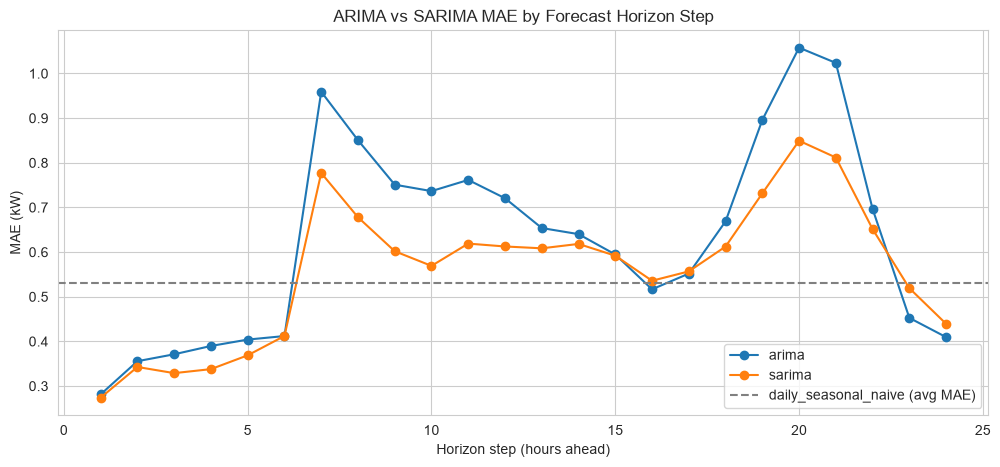

In [11]:
horizon_metrics = (
    combined_results.groupby(["method", "horizon_step"])
    .apply(lambda d: pd.Series(compute_metrics(d)))
    .reset_index()
)

fig, ax = plt.subplots()
for name in ["arima", "sarima"]:
    subset = horizon_metrics[horizon_metrics["method"] == name]
    ax.plot(subset["horizon_step"], subset["MAE"], marker="o", label=name)
ax.axhline(0.530485, color="gray", linestyle="--", label="daily_seasonal_naive (avg MAE)")
ax.set_xlabel("Horizon step (hours ahead)")
ax.set_ylabel("MAE (kW)")
ax.set_title("ARIMA vs SARIMA MAE by Forecast Horizon Step")
ax.legend()
plt.show()


## MLflow experiment tracking

In [ ]:
mlflow.set_tracking_uri(f"file://{PROJECT_ROOT / 'mlruns'}")
mlflow.set_experiment("energy-demand-forecasting")

for name, fitted, metrics_dict in [
    ("arima", arima_fit, summary["arima"]),
    ("sarima", sarima_fit, summary["sarima"]),
]:
    with mlflow.start_run(run_name=f"{name}_24h"):
        mlflow.log_param("order", str(order))
        mlflow.log_param("seasonal_order", str(seasonal_order if name == "sarima" else (0, 0, 0, 0)))
        mlflow.log_param("fit_window_hours", len(fit_window))
        mlflow.log_metric("aic", fitted.aic)
        for metric_name, value in metrics_dict.items():
            if metric_name != "n":
                mlflow.log_metric(metric_name.lower(), value)

print("Logged to MLflow -- run `uv run mlflow ui` to view.")


## Save results for Phase 9

In [13]:
save_results(combined_results, "sarima_arima")


Saved 13,824 rows -> /Users/apple/Documents/Projects/energy-demand-forecast/data/results/sarima_arima.parquet


## SARIMA / ARIMA Findings

- **Chosen order from auto_arima:** ARIMA(3,1,0)(2,0,0)[24] -- three
  non-seasonal AR terms, one order of differencing, no MA terms, plus two
  seasonal AR terms at lags 24 and 48 (no seasonal differencing needed --
  the seasonal AR terms alone capture the daily cycle without D=1).

- **Stationarity conclusion:** ADF and KPSS *disagreed* on the raw series
  (ADF said stationary, p=0.0000; KPSS said non-stationary, p=0.01) -- a
  known real-world pattern, since ADF has limited power against some
  non-stationary alternatives that KPSS catches. After first-differencing,
  both tests agreed the series is stationary (ADF p=0.0000, KPSS p=0.1, at
  the edge of its table meaning even stronger stationarity than reported).
  d=1 is well justified, and it's exactly what auto_arima picked
  independently -- good agreement between the manual test and the automated
  search.

- **ARIMA vs. SARIMA -- the seasonal term earned its complexity, clearly, on
  fit quality:** SARIMA's AIC (8531.4) is substantially lower than plain
  ARIMA's (8994.5) on the same fit window with the same non-seasonal order --
  a large, unambiguous improvement from adding the seasonal AR terms alone.

- **But did SARIMA beat the Phase 5 baseline? Mixed, and worth reporting
  exactly as mixed:**

  | Method | MAE | RMSE | MAPE | sMAPE |
  |---|---|---|---|---|
  | daily_seasonal_naive (Phase 5) | **0.530** | 0.786 | 67.3% | 49.5% |
  | sarima | 0.560 | **0.776** | 72.1% | 57.5% |
  | arima | 0.631 | 0.871 | 72.6% | 63.0% |

  SARIMA's RMSE is actually slightly *better* than the baseline's, but its
  MAE is slightly *worse*. That divergence is informative, not noise: RMSE
  penalizes large errors much more heavily (squared), so a lower RMSE
  alongside a higher MAE suggests SARIMA makes fewer big, blow-up-sized
  misses than the naive lag-24 lookup (which just repeats yesterday's value
  verbatim, including any anomalous spike), at the cost of being slightly
  less precise on typical, unremarkable hours where the naive lookup is
  already very good. **This is a genuine interpretability-vs-robustness
  trade-off**, not a clean win for either side -- worth stating exactly this
  way in the portfolio writeup rather than picking whichever metric makes
  SARIMA look better.

- **Plain ARIMA is clearly worse than both** on every metric -- confirms in
  the actual forecasting task what the AIC already suggested: the seasonal
  structure matters enough that skipping it costs real accuracy, not just
  model-fit elegance.

- **Residual diagnostics reveal a real, honest limitation:** the Ljung-Box
  test is highly significant at both lag 24 (stat=214.1, p≈2e-32) and lag 48
  (stat=343.1, p≈3e-46) -- meaning the residuals are still significantly
  autocorrelated even after fitting. The model hasn't fully captured the
  series' structure. The most likely missing piece is weekly (168h)
  periodicity, which this SARIMA config deliberately doesn't model (m=24
  only, for the computational-tractability reasons discussed before fitting).
  Residuals are also non-normal (Jarque-Bera highly significant, skew=0.41,
  kurtosis=4.95 -- heavier-tailed and right-skewed than a normal
  distribution), consistent with the occasional high-consumption spikes
  found back in Phase 3's anomaly detection.

- **Metric caveat carried forward from Phase 5:** MAPE/sMAPE remain inflated
  (57-73% across all three methods) for the same reason as before --
  overnight low-consumption hours near zero distort percentage-based
  metrics. MAE/RMSE remain the trustworthy numbers for this dataset.

- **What this means for Phase 7/8:** SARIMA didn't decisively beat a trivial
  baseline at the 24h horizon, largely because it's structurally blind to
  weekly seasonality (a limitation we accepted upfront for tractability).
  Prophet and LightGBM don't have that same m=168 tractability problem --
  Prophet handles multiple seasonalities natively, and LightGBM can just add
  weekly-lag features directly (which Phase 4 already built). If either of
  those clears the baseline more convincingly, the weekly-seasonality gap is
  a defensible, well-evidenced explanation for *why* SARIMA specifically
  struggled here -- a good comparison story, not just "SARIMA is worse."
